In [1]:
# import scipy.special for the sigmoid function expit()
import scipy.special, numpy
import matplotlib.pyplot as plt

# Neural network class definition
class NeuralNetwork:
    # Init the network, this gets run whenever we make a new instance of this class
    def __init__(self, input_nodes, hidden_nodes, output_nodes, learning_rate):
        # Set the number of nodes in each input, hidden and output layer
        self.i_nodes = input_nodes
        self.h_nodes = hidden_nodes
        self.o_nodes = output_nodes

        # Weight matrices, with (input -> hidden) and who (hidden -> output)
        self.wih = numpy.random.normal(0.0, pow(self.h_nodes, -0.5), (self.h_nodes, self.i_nodes))
        self.who = numpy.random.normal(0.0, pow(self.o_nodes, -0.5), (self.o_nodes, self.h_nodes))

        # Set the learning rate
        self.lr = learning_rate

        # Set the activation function, the logistic sigmoid
        self.activation_function = lambda x: scipy.special.expit(x)

    # Train the network using back-propagation of errors
    def train(self, inputs_list, targets_list):
        # Convert inputs into 2D arrays
        inputs_array = numpy.array(inputs_list, ndmin=2).T
        targets_array = numpy.array(targets_list, ndmin=2).T

        # Calculate signals into hidden layer
        hidden_inputs = numpy.dot(self.wih, inputs_array)

        # Calculate signals emerging from hidden layer
        hidden_outputs = self.activation_function(hidden_inputs)

        # Calculate signals into final output layer
        final_inputs = numpy.dot(self.who, hidden_outputs)

        # Calculate the signals emerging from final output layer
        final_outputs = self.activation_function(final_inputs)

        # Current error is (target - actual)
        output_errors = targets_array - final_outputs

        # Hidden layer errors are the output errors, split by the weights, recombined at hidden nodes
        hidden_errors = numpy.dot(self.who.T, output_errors)

        # Update the weights for the links between the hidden and output layers
        self.who += self.lr*numpy.dot((output_errors*final_outputs*(1.0 - final_outputs)), numpy.transpose(hidden_outputs))
        # Update the weights for the links between the input and hidden layers
        self.wih += self.lr*numpy.dot((hidden_errors*hidden_outputs*(1.0 - hidden_outputs)), numpy.transpose(inputs_array))

    # Query the network
    def query(self, inputs_list):
        # Converts the inputs list into a 2D array
        inputs_array = numpy.array(inputs_list, ndmin=2).T

        # Calcualte the signals into hidden layer
        hidden_inputs = numpy.dot(self.wih, inputs_array) 

        # Calculate output from the hidden layer
        hidden_outputs = self.activation_function(hidden_inputs)

        # Calculate signals into final layer
        final_inputs = numpy.dot(self.who, hidden_outputs)

        # Calculate outputs from the final layer
        final_outputs = self.activation_function(final_inputs)
        print(final_outputs)
        return final_outputs

In [5]:

# Plotting planes for decision boundaries
nn3 = NeuralNetwork(2, 5, 1, 0.25)
inputs = [[0,0], [0,1], [1,0], [1,1]]
targets = [[0], [0], [0], [1]]
for j in range(1000):
        nn3.train(inputs, targets)
        nn3.query(inputs)
nn3.query(inputs)

# print(nn3.wih)
# print(nn3.who)
outputs = [[0], [1], [1], [0]]

[[0.41110593 0.44307112 0.46850096 0.49263737]]
[[0.39594259 0.43179074 0.45571913 0.48375759]]
[[0.38180213 0.42130194 0.44378636 0.47555096]]
[[0.3686305  0.41156357 0.43266311 0.46798441]]
[[0.35636821 0.40253146 0.42230561 0.46102298]]
[[0.34495352 0.39416014 0.41266786 0.45463069]]
[[0.33432467 0.38640407 0.40370312 0.44877124]]
[[0.32442149 0.37921864 0.39536512 0.44340862]]
[[0.31518647 0.37256079 0.38760882 0.43850758]]
[[0.30656539 0.3663895  0.38039105 0.43403406]]
[[0.29850772 0.36066607 0.37367087 0.42995541]]
[[0.29096668 0.35535424 0.36740977 0.42624059]]
[[0.28389928 0.35042028 0.36157176 0.42286036]]
[[0.27726615 0.3458329  0.35612344 0.41978726]]
[[0.27103134 0.34156327 0.35103387 0.41699571]]
[[0.26516217 0.33758482 0.34627454 0.41446192]]
[[0.25962889 0.33387319 0.34181922 0.41216392]]
[[0.2544045  0.33040604 0.33764384 0.41008144]]
[[0.24946451 0.32716295 0.33372635 0.40819587]]
[[0.24478666 0.32412524 0.33004656 0.40649013]]
[[0.24035079 0.32127587 0.32658601 0.404

In [3]:
# set the axis limits
x = numpy.linspace((-2,-2),(2,2),50).T
linear_separator1 = []
linear_separator2 = []
linear_separator3 = []
linear_separator4 = []
linear_separator5 = []
for m in range(len(x)):
    linear_separator1.append((-nn3.wih[0][0]/nn3.wih[0][1])*x[m] - (1/-nn3.wih[0][1]))
    linear_separator2.append((-nn3.wih[1][0]/nn3.wih[1][1])*x[m] - (1/-nn3.wih[1][1]))
    linear_separator3.append((-nn3.wih[2][0]/nn3.wih[2][1])*x[m] - (1/-nn3.wih[2][1]))
    linear_separator4.append((-nn3.wih[3][0]/nn3.wih[3][1])*x[m] - (1/-nn3.wih[3][1]))
    linear_separator5.append((-nn3.wih[4][0]/nn3.wih[4][1])*x[m] - (1/-nn3.wih[4][1]))

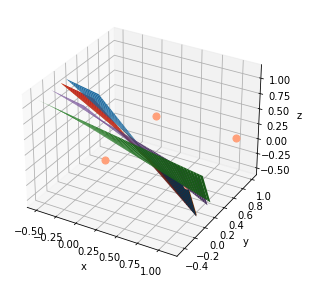

In [4]:
fig = plt.figure(num=1, clear=True)
ax = fig.add_subplot(1, 1, 1, projection='3d')

x =  numpy.linspace((-0.5,-0.1),(1,1.1),50).T
y = x #numpy.array(linear_separator1)
z1 = numpy.array(linear_separator1)*1/20
z2 = numpy.array(linear_separator2)*1/20
z3 = numpy.array(linear_separator3)*1/20
z4 = numpy.array(linear_separator4)*1/20
z5 = numpy.array(linear_separator5)*1/20

ax.plot_surface(x, z1, numpy.flip(x))
ax.plot_surface(x, z2, numpy.flip(x))
ax.plot_surface(x, z4, numpy.flip(x))
ax.plot_surface(x, z3, numpy.flip(x))
ax.plot_surface(x, z5, numpy.flip(x))

i = 0
for out in outputs:
    if out == 1:
        ax.scatter(inputs[i][0],inputs[i][1],0, s=50, color='aquamarine', zorder=3)
    else:
        ax.scatter(inputs[i][0],inputs[i][1],0, s=50, color='lightsalmon', zorder=3)
    i = i+1

ax.set(xlabel='x', ylabel='y', zlabel='z')

fig.tight_layout()